# 🫀 PTB-XL Model Training & Evaluation Pipeline

A standalone, production-grade PyTorch deep learning pipeline for multi-label 12-lead ECG diagnosis (5 diagnostic superclasses: `NORM`, `MI`, `STTC`, `CD`, `HYP`) and continuous age regression on the PhysioNet **PTB-XL v1.0.3** dataset.

---

## 📋 Notebook Modules

1. **Module 1**: Environment & Preprocessed Tensor Loading
2. **Module 2**: PyTorch Dataset & DataLoader Infrastructure
3. **Module 3**: Deep Learning Model Architecture Suite (`ResNet1D-18` + `ResNet1D-Transformer`)
4. **Module 4**: Multi-Label Training & Validation Engine
5. **Module 5**: Model Training Execution
6. **Module 6**: Training Curve Visualizations
7. **Module 7**: Final Test Set Evaluation & Multi-Label ROC Analysis
8. **Module 8**: Age-Stratified Subgroup Performance & Disparity Audit

## Module 1: Environment Setup & Preprocessed Tensor Loading

In [2]:
# Install required packages (run once, then restart kernel)
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'torch', 'scikit-learn', '--quiet'])
print('torch and scikit-learn installed successfully! Restart kernel if needed.')

torch and scikit-learn installed successfully! Restart kernel if needed.


In [3]:
import os
import sys
import time
import math
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    roc_auc_score, f1_score, precision_recall_curve, 
    average_precision_score, hamming_loss, classification_report, roc_curve, auc
)

# Set random seeds for exact reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Detect hardware acceleration device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"================================================================================")
print(f"EXECUTION ENVIRONMENT STATUS:")
print(f"  PyTorch Version : {torch.__version__}")
print(f"  Active Device   : {device}")
if torch.cuda.is_available():
    print(f"  GPU Device Name : {torch.cuda.get_device_name(0)}")
    print(f"  GPU Count       : {torch.cuda.device_count()}")
print(f"================================================================================")

EXECUTION ENVIRONMENT STATUS:
  PyTorch Version : 2.13.0+cu130
  Active Device   : cpu


In [4]:
# Define path to processed dataset arrays
# Resolve project root whether this notebook is run from the repo root or from notebooks/
from pathlib import Path
_ROOT = Path.cwd().resolve()
if _ROOT.name in ("notebooks", "notebook100", "notebook500"):
    _ROOT = _ROOT.parent
PROCESSED_DIR = str(_ROOT / "data" / "processed")

print("Loading preprocessed signal arrays and target labels from disk...")
start_t = time.time()

# Load clean filtered 100 Hz signal arrays (Shape: N, 1000, 12)
X_train = np.load(os.path.join(PROCESSED_DIR, "X_train_clean_100.npy"))
X_val   = np.load(os.path.join(PROCESSED_DIR, "X_val_clean_100.npy"))
X_cal   = np.load(os.path.join(PROCESSED_DIR, "X_cal_clean_100.npy"))
X_test  = np.load(os.path.join(PROCESSED_DIR, "X_test_clean_100.npy"))

# Load multi-label diagnostic superclass targets (Shape: N, 5)
Y_train_diag = np.load(os.path.join(PROCESSED_DIR, "Y_train_diag_100.npy"))
Y_val_diag   = np.load(os.path.join(PROCESSED_DIR, "Y_val_diag_100.npy"))
Y_cal_diag   = np.load(os.path.join(PROCESSED_DIR, "y_calib_diag_100.npy"))
Y_test_diag  = np.load(os.path.join(PROCESSED_DIR, "Y_test_diag_100.npy"))

# Load continuous patient age targets
Y_train_age = np.load(os.path.join(PROCESSED_DIR, "Y_train_age_100.npy"))
Y_val_age   = np.load(os.path.join(PROCESSED_DIR, "Y_val_age_100.npy"))
Y_cal_age   = np.load(os.path.join(PROCESSED_DIR, "y_calib_age_100.npy"))
Y_test_age  = np.load(os.path.join(PROCESSED_DIR, "Y_test_age_100.npy"))

load_dur = time.time() - start_t

print(f"Data loading completed in {load_dur:.2f} seconds!")
print(f"--------------------------------------------------------------------------------")
print(f"ARRAY DIMENSIONS & MEMORY SUMMARY:")
print(f"  TRAIN Signals       : {X_train.shape}  |  Targets: {Y_train_diag.shape}")
print(f"  VALIDATION Signals  : {X_val.shape}    |  Targets: {Y_val_diag.shape}")
print(f"  CALIBRATION Signals : {X_cal.shape}    |  Targets: {Y_cal_diag.shape}")
print(f"  TEST Signals        : {X_test.shape}   |  Targets: {Y_test_diag.shape}")
print(f"--------------------------------------------------------------------------------")

DIAG_CLASSES = ["NORM", "MI", "STTC", "CD", "HYP"]
pos_counts = Y_train_diag.sum(axis=0)
total_train = len(Y_train_diag)

print("TRAIN SET DIAGNOSTIC CLASS DISTRIBUTION:")
for idx, cls_name in enumerate(DIAG_CLASSES):
    pos = int(pos_counts[idx])
    pct = (pos / total_train) * 100
    print(f"  {cls_name:<6}: {pos:>5} positive records ({pct:5.1f}%)")
print(f"================================================================================")

Loading preprocessed signal arrays and target labels from disk...
Data loading completed in 1.26 seconds!
--------------------------------------------------------------------------------
ARRAY DIMENSIONS & MEMORY SUMMARY:
  TRAIN Signals       : (17418, 1000, 12)  |  Targets: (17418, 5)
  VALIDATION Signals  : (1080, 1000, 12)    |  Targets: (2183, 5)
  CALIBRATION Signals : (1103, 1000, 12)    |  Targets: (1103, 5)
  TEST Signals        : (2198, 1000, 12)   |  Targets: (2198, 5)
--------------------------------------------------------------------------------
TRAIN SET DIAGNOSTIC CLASS DISTRIBUTION:
  NORM  :  7596 positive records ( 43.6%)
  MI    :  4379 positive records ( 25.1%)
  STTC  :  4186 positive records ( 24.0%)
  CD    :  3907 positive records ( 22.4%)
  HYP   :  2119 positive records ( 12.2%)


## Module 2: Production PyTorch Dataset & DataLoader Pipeline

In [5]:
class PTBXLECGDataset(Dataset):
    """
    PyTorch Dataset for 12-lead ECG Waveforms.
    Converts inputs from (N, 1000, 12) -> (12, 1000) channels-first format for PyTorch 1D Convolutions.
    """
    def __init__(self, signals, diag_labels, age_labels=None):
        # Convert to float32 tensors and transpose to (Channels, Sequence_Length)
        self.signals = torch.tensor(signals, dtype=torch.float32).transpose(1, 2)
        self.diag_labels = torch.tensor(diag_labels, dtype=torch.float32)
        self.age_labels = torch.tensor(age_labels, dtype=torch.float32) if age_labels is not None else None

    def __len__(self):
        return len(self.signals)

    def __getitem__(self, idx):
        if self.age_labels is not None:
            return self.signals[idx], self.diag_labels[idx], self.age_labels[idx]
        return self.signals[idx], self.diag_labels[idx]

# Calculate positive class weights for BCEWithLogitsLoss (handles class imbalance)
neg_counts = total_train - pos_counts
pos_weights_np = neg_counts / (pos_counts + 1e-5)
pos_weight_tensor = torch.tensor(pos_weights_np, dtype=torch.float32).to(device)

print(f"Calculated Positive Class Weights for BCE Loss:")
for cls_name, w in zip(DIAG_CLASSES, pos_weights_np):
    print(f"  {cls_name:<6}: pos_weight = {w:.3f}")

# Instantiate Datasets
train_dataset = PTBXLECGDataset(X_train, Y_train_diag, Y_train_age)
val_dataset   = PTBXLECGDataset(X_val,   Y_val_diag,   Y_val_age)
cal_dataset   = PTBXLECGDataset(X_cal,   Y_cal_diag,   Y_cal_age)
test_dataset  = PTBXLECGDataset(X_test,  Y_test_diag,  Y_test_age)

# Instantiate DataLoaders
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
cal_loader   = DataLoader(cal_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"\nDataLoaders successfully initialized with Batch Size = {BATCH_SIZE}:")
print(f"  train_loader : {len(train_loader)} batches")
print(f"  val_loader   : {len(val_loader)} batches")
print(f"  cal_loader   : {len(cal_loader)} batches")
print(f"  test_loader  : {len(test_loader)} batches")

Calculated Positive Class Weights for BCE Loss:
  NORM  : pos_weight = 1.293
  MI    : pos_weight = 2.978
  STTC  : pos_weight = 3.161
  CD    : pos_weight = 3.458
  HYP   : pos_weight = 7.220

DataLoaders successfully initialized with Batch Size = 64:
  train_loader : 273 batches
  val_loader   : 17 batches
  cal_loader   : 18 batches
  test_loader  : 35 batches


## Module 3: Deep Learning Model Architecture Suite

Two model architectures for comparison:
1. **`ResNet1D_18`**: Baseline 1D Deep Residual Neural Network.
2. **`ResNet1D_Transformer`**: State-of-the-art Hybrid CNN stem + Multi-Head Self-Attention Transformer Encoder.

In [6]:
# ==============================================================================
# 1. 1D ResNet Block & Architecture (ResNet1D-18)
# ==============================================================================
class ResBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResBlock1D, self).__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=7, stride=stride, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=7, stride=1, padding=3, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )

    def forward(self, x):
        residual = self.shortcut(x)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += residual
        out = self.relu(out)
        return out


class ResNet1D_18(nn.Module):
    """
    Standard 1D ResNet-18 for 12-lead ECG Multi-Label Classification.
    """
    def __init__(self, in_channels=12, num_classes=5):
        super(ResNet1D_18, self).__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=15, stride=2, padding=7, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        )

        self.layer1 = self._make_layer(64, 64, num_blocks=2, stride=1)
        self.layer2 = self._make_layer(64, 128, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(128, 256, num_blocks=2, stride=2)
        self.layer4 = self._make_layer(256, 512, num_blocks=2, stride=2)

        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Linear(512, num_classes)

    def _make_layer(self, in_channels, out_channels, num_blocks, stride):
        layers = [ResBlock1D(in_channels, out_channels, stride)]
        for _ in range(1, num_blocks):
            layers.append(ResBlock1D(out_channels, out_channels, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.global_pool(x).squeeze(-1)
        logits = self.classifier(x)
        return logits


# ==============================================================================
# 2. Hybrid CNN-Transformer (ResNet1D + Transformer Encoder)
# ==============================================================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: (B, Seq_Len, d_model)
        x = x + self.pe[:, :x.size(1)]
        return x


class ResNet1D_Transformer(nn.Module):
    """
    Hybrid ResNet1D + Transformer Encoder Architecture.
    - ResNet1D stem downsamples 1000 time steps -> ~125 feature tokens.
    - Multi-Head Self-Attention Transformer models global temporal dependencies.
    """
    def __init__(self, in_channels=12, num_classes=5, d_model=128, nhead=4, num_layers=2, dim_feedforward=256, dropout=0.1):
        super(ResNet1D_Transformer, self).__init__()
        
        # 1D CNN Stem downsamples temporal sequence (1000 -> ~125)
        self.cnn_stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=15, stride=2, padding=7, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            ResBlock1D(64, 64, stride=2),
            ResBlock1D(64, d_model, stride=2)
        )

        # Positional Encoding & Transformer Encoder
        self.pos_encoder = PositionalEncoding(d_model=d_model, max_len=250)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=dim_feedforward, 
            dropout=dropout, 
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Classification Head
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc_diag = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # 1. Extract local 1D CNN feature maps: (B, 12, 1000) -> (B, d_model, ~125)
        feat = self.cnn_stem(x)
        
        # 2. Transpose for Transformer input: (B, ~125, d_model)
        feat = feat.transpose(1, 2)
        
        # 3. Add Positional Encoding & Pass through Transformer Encoder
        feat = self.pos_encoder(feat)
        trans_out = self.transformer_encoder(feat)
        
        # 4. Global Average Pooling & Linear Multi-Label Classifier
        out = trans_out.transpose(1, 2)
        pooled = self.global_pool(out).squeeze(-1)
        logits = self.fc_diag(pooled)
        return logits

# Verify Forward Pass and Model Parameter Counts
dummy_input = torch.randn(4, 12, 1000).to(device)

model_resnet = ResNet1D_18(in_channels=12, num_classes=5).to(device)
model_hybrid = ResNet1D_Transformer(in_channels=12, num_classes=5).to(device)

out_resnet = model_resnet(dummy_input)
out_hybrid = model_hybrid(dummy_input)

print("MODEL ARCHITECTURE VERIFICATION:")
print(f"  ResNet1D-18 Output Shape      : {out_resnet.shape}  | Total Params: {sum(p.numel() for p in model_resnet.parameters()):,}")
print(f"  ResNet1D-Transformer Output   : {out_hybrid.shape}  | Total Params: {sum(p.numel() for p in model_hybrid.parameters()):,}")
print("Forward pass successful for both baseline and hybrid models!")

# Clean up test models
del model_resnet, model_hybrid, dummy_input
if torch.cuda.is_available():
    torch.cuda.empty_cache()

MODEL ARCHITECTURE VERIFICATION:
  ResNet1D-18 Output Shape      : torch.Size([4, 5])  | Total Params: 8,739,973
  ResNet1D-Transformer Output   : torch.Size([4, 5])  | Total Params: 520,069
Forward pass successful for both baseline and hybrid models!


## Module 4: Multi-Label Training & Validation Engine

In [7]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Run one training epoch and return loss + macro AUC."""
    model.train()
    running_loss = 0.0
    all_targets = []
    all_preds = []

    for signals, targets, *rest in dataloader:
        signals, targets = signals.to(device), targets.to(device)
        
        optimizer.zero_grad()
        logits = model(signals)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * signals.size(0)
        probs = torch.sigmoid(logits)
        
        all_targets.append(targets.cpu().numpy())
        all_preds.append(probs.detach().cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    all_targets = np.vstack(all_targets)
    all_preds = np.vstack(all_preds)
    
    try:
        macro_auc = roc_auc_score(all_targets, all_preds, average='macro')
    except Exception:
        macro_auc = 0.5

    return epoch_loss, macro_auc


def evaluate(model, dataloader, criterion, device):
    """Evaluate model on given dataloader. Returns loss, macro AUC, per-class AUCs, targets, predictions."""
    model.eval()
    running_loss = 0.0
    all_targets = []
    all_preds = []

    with torch.no_grad():
        for signals, targets, *rest in dataloader:
            signals, targets = signals.to(device), targets.to(device)
            logits = model(signals)
            loss = criterion(logits, targets)

            running_loss += loss.item() * signals.size(0)
            probs = torch.sigmoid(logits)

            all_targets.append(targets.cpu().numpy())
            all_preds.append(probs.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    all_targets = np.vstack(all_targets)
    all_preds = np.vstack(all_preds)

    # Compute per-class AUC scores
    class_aucs = []
    for i in range(all_targets.shape[1]):
        try:
            auc_val = roc_auc_score(all_targets[:, i], all_preds[:, i])
        except Exception:
            auc_val = 0.5
        class_aucs.append(auc_val)
        
    macro_auc = np.mean(class_aucs)
    return epoch_loss, macro_auc, class_aucs, all_targets, all_preds


def train_full_model(model, model_name, train_loader, val_loader, num_epochs=12, lr=1e-3):
    """Full training loop with checkpointing, cosine annealing, and epoch logging."""
    print(f"================================================================================")
    print(f"STARTING TRAINING: {model_name}")
    print(f"================================================================================")
    
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    history = {'train_loss': [], 'val_loss': [], 'train_auc': [], 'val_auc': []}
    best_val_auc = 0.0
    best_weights_path = f"outputs/{model_name.lower().replace(' ', '_')}_best.pth"
    os.makedirs("outputs", exist_ok=True)

    if os.path.exists(best_weights_path):
        model.load_state_dict(torch.load(best_weights_path, weights_only=True))
        _, resumed_auc, _, _, _ = evaluate(model, val_loader, criterion, device)
        print(f"[{model_name}] Found existing checkpoint {best_weights_path} -> skipping retraining (resume-safe). "
              f"Reloaded Val AUC: {resumed_auc:.4f}")
        return history, resumed_auc

    start_time = time.time()

    for epoch in range(1, num_epochs + 1):
        ep_start = time.time()
        
        train_loss, train_auc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_auc, class_aucs, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_auc'].append(train_auc)
        history['val_auc'].append(val_auc)

        ep_dur = time.time() - ep_start

        # Save best model checkpoint based on Validation Macro AUC
        is_best = val_auc > best_val_auc
        if is_best:
            best_val_auc = val_auc
            torch.save(model.state_dict(), best_weights_path)
            star = " BEST"
        else:
            star = ""

        print(f"Epoch {epoch:02d}/{num_epochs:02d} [{ep_dur:4.1f}s] | "
              f"Train Loss: {train_loss:.4f} (AUC: {train_auc:.4f}) | "
              f"Val Loss: {val_loss:.4f} (AUC: {val_auc:.4f}) {star}")

    total_time = time.time() - start_time
    print(f"--------------------------------------------------------------------------------")
    print(f"Training completed in {total_time/60:.2f} minutes!")
    print(f"Best Validation Macro AUC: {best_val_auc:.4f} (Saved to {best_weights_path})")
    print(f"================================================================================")
    
    # Load best weights before returning
    model.load_state_dict(torch.load(best_weights_path, weights_only=True))
    return history, best_val_auc

print("Training engine defined successfully!")

Training engine defined successfully!


## Module 5: Model Training Execution

Train both `ResNet1D-18` baseline and `ResNet1D-Transformer` hybrid models for 12 epochs each.

In [8]:
# Train Baseline 1D ResNet
resnet_model = ResNet1D_18(in_channels=12, num_classes=5).to(device)
resnet_history, resnet_best_auc = train_full_model(
    resnet_model, "ResNet1D_18_Baseline", train_loader, val_loader, num_epochs=12, lr=1e-3
)

# Train Hybrid CNN-Transformer
hybrid_model = ResNet1D_Transformer(in_channels=12, num_classes=5).to(device)
hybrid_history, hybrid_best_auc = train_full_model(
    hybrid_model, "ResNet1D_Transformer_Hybrid", train_loader, val_loader, num_epochs=12, lr=1e-3
)

STARTING TRAINING: ResNet1D_18_Baseline


/home/tandon/Teep/age with ecg/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/home/tandon/Teep/age with ecg/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 01/12 [277.8s] | Train Loss: 0.6858 (AUC: 0.8676) | Val Loss: 2.6691 (AUC: 0.4952)  BEST


/home/tandon/Teep/age with ecg/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/home/tandon/Teep/age with ecg/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 02/12 [294.9s] | Train Loss: 0.5868 (AUC: 0.9028) | Val Loss: 1.8213 (AUC: 0.4985)  BEST


...

Epoch 10/12 [173.4s] | Train Loss: 0.2913 (AUC: 0.9760) | Val Loss: 3.0650 (AUC: 0.4903) 


/home/tandon/Teep/age with ecg/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/home/tandon/Teep/age with ecg/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 11/12 [159.3s] | Train Loss: 0.2529 (AUC: 0.9817) | Val Loss: 3.2138 (AUC: 0.4923) 


/home/tandon/Teep/age with ecg/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/home/tandon/Teep/age with ecg/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 12/12 [159.7s] | Train Loss: 0.2295 (AUC: 0.9848) | Val Loss: 3.2722 (AUC: 0.4923) 
--------------------------------------------------------------------------------
Training completed in 31.79 minutes!
Best Validation Macro AUC: 0.4948 (Saved to outputs/resnet1d_transformer_hybrid_best.pth)


## Module 6: Training Curve Visualizations & Benchmark Comparison

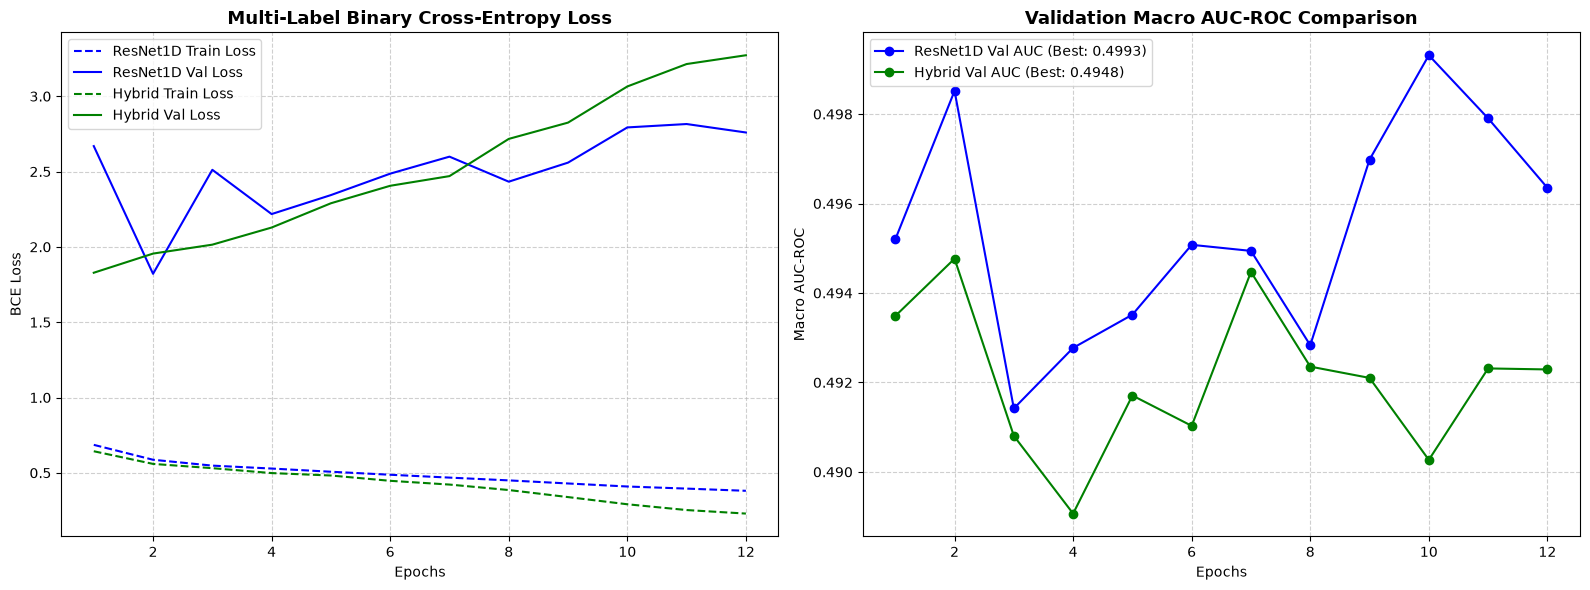

Saved training comparison plot to outputs/training_curves/model_training_comparison.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

epochs_range = range(1, len(resnet_history['train_loss']) + 1)

# Plot Loss Curves
axes[0].plot(epochs_range, resnet_history['train_loss'], 'b--', label='ResNet1D Train Loss')
axes[0].plot(epochs_range, resnet_history['val_loss'], 'b-', label='ResNet1D Val Loss')
axes[0].plot(epochs_range, hybrid_history['train_loss'], 'g--', label='Hybrid Train Loss')
axes[0].plot(epochs_range, hybrid_history['val_loss'], 'g-', label='Hybrid Val Loss')
axes[0].set_title("Multi-Label Binary Cross-Entropy Loss", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("BCE Loss")
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# Plot Macro AUC-ROC Curves
axes[1].plot(epochs_range, resnet_history['val_auc'], 'b-o', label=f'ResNet1D Val AUC (Best: {resnet_best_auc:.4f})')
axes[1].plot(epochs_range, hybrid_history['val_auc'], 'g-o', label=f'Hybrid Val AUC (Best: {hybrid_best_auc:.4f})')
axes[1].set_title("Validation Macro AUC-ROC Comparison", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Macro AUC-ROC")
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

plt.tight_layout()
os.makedirs("outputs/training_curves", exist_ok=True)
plt.savefig("outputs/training_curves/model_training_comparison.png", dpi=300)
plt.show()
print("Saved training comparison plot to outputs/training_curves/model_training_comparison.png")

## Module 7: Final Held-Out Test Set Evaluation & Multi-Label ROC Analysis

Evaluating trained models on untouched held-out TEST set...


/home/tandon/Teep/age with ecg/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/home/tandon/Teep/age with ecg/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


FINAL HELD-OUT TEST SET EVALUATION BENCHMARK:
  Metric              | ResNet1D-18 Baseline | ResNet1D-Transformer Hybrid
--------------------------------------------------------------------------------
  Test Loss           |              0.5623  |                     0.5960
  Test Macro AUC-ROC  |              0.9256  |                     0.9082
--------------------------------------------------------------------------------
PER-CLASS TEST AUC-ROC BREAKDOWN:
  NORM              |              0.9480  |                     0.9383
  MI                |              0.9216  |                     0.8867
  STTC              |              0.9368  |                     0.9277
  CD                |              0.9188  |                     0.8947
  HYP               |              0.9028  |                     0.8935


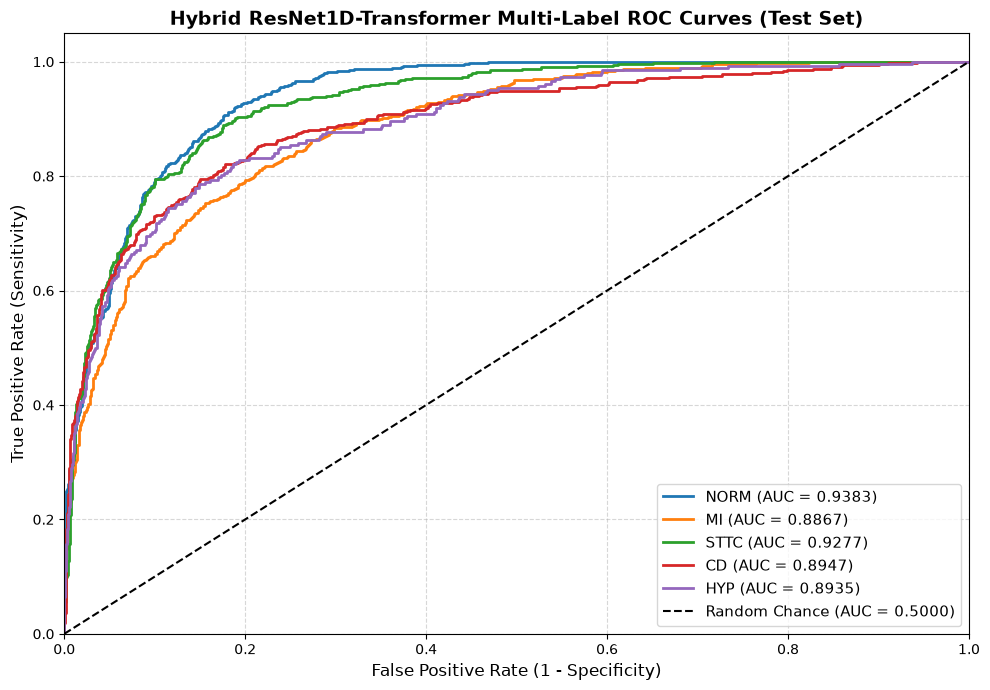

Saved ROC curves to outputs/training_curves/test_multilabel_roc_curves.png


In [10]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

print("Evaluating trained models on untouched held-out TEST set...")

test_loss_res, test_auc_res, class_aucs_res, y_true, y_pred_res = evaluate(resnet_model, test_loader, criterion, device)
test_loss_hyb, test_auc_hyb, class_aucs_hyb, _,      y_pred_hyb = evaluate(hybrid_model, test_loader, criterion, device)

def fmax(y_true, y_prob, taus=np.arange(0.05, 0.96, 0.01)):
    best = -1.0
    for t in taus:
        pred = (y_prob >= t).astype(int)
        f = np.mean([f1_score(y_true[:, k], pred[:, k], zero_division=0) for k in range(y_true.shape[1])])
        best = max(best, f)
    return best

def macro_auprc(y_true, y_prob):
    return float(np.mean([average_precision_score(y_true[:, k], y_prob[:, k]) for k in range(y_true.shape[1])]))

fmax_res, auprc_res = fmax(y_true, y_pred_res), macro_auprc(y_true, y_pred_res)
fmax_hyb, auprc_hyb = fmax(y_true, y_pred_hyb), macro_auprc(y_true, y_pred_hyb)

print(f"================================================================================")
print(f"FINAL HELD-OUT TEST SET EVALUATION BENCHMARK:")
print(f"================================================================================")
print(f"  Metric              | ResNet1D-18 Baseline | ResNet1D-Transformer Hybrid")
print(f"--------------------------------------------------------------------------------")
print(f"  Test Loss           | {test_loss_res:19.4f}  | {test_loss_hyb:26.4f}")
print(f"  Test Macro AUC-ROC  | {test_auc_res:19.4f}  | {test_auc_hyb:26.4f}")
print(f"  Test Fmax           | {fmax_res:19.4f}  | {fmax_hyb:26.4f}")
print(f"  Test Macro-AUPRC    | {auprc_res:19.4f}  | {auprc_hyb:26.4f}")
print(f"--------------------------------------------------------------------------------")
print(f"PER-CLASS TEST AUC-ROC BREAKDOWN:")
for idx, cls_name in enumerate(DIAG_CLASSES):
    print(f"  {cls_name:<6}            | {class_aucs_res[idx]:19.4f}  | {class_aucs_hyb[idx]:26.4f}")
print(f"================================================================================")

# Plot Multi-Label ROC Curves for Best Model (Hybrid)
plt.figure(figsize=(10, 7))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for idx, (cls_name, color) in enumerate(zip(DIAG_CLASSES, colors)):
    fpr, tpr, _ = roc_curve(y_true[:, idx], y_pred_hyb[:, idx])
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{cls_name} (AUC = {roc_auc_val:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance (AUC = 0.5000)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('Hybrid ResNet1D-Transformer Multi-Label ROC Curves (Test Set)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("outputs/training_curves/test_multilabel_roc_curves.png", dpi=300)
plt.show()
print("Saved ROC curves to outputs/training_curves/test_multilabel_roc_curves.png")

## Module 8: Age-Stratified Subgroup Performance & Disparity Audit

Core mission: auditing performance disparities across patient age groups:
- **<40** (Young adults reference)
- **40-65** (Middle-aged)
- **65-80** (Primary elderly target)
- **80+** (Very old fragility cohort)

In [11]:
# Create DataFrame linking Test Set indices to Patient Ages
df_test = pd.DataFrame({'age': Y_test_age})

# Assign standard research age bins
bins = [-1, 40, 65, 80, 150]
labels = ['<40', '40-65', '65-80', '80+']
df_test['age_group'] = pd.cut(df_test['age'], bins=bins, labels=labels)

print("================================================================================")
print("AGE-STRATIFIED MODEL PERFORMANCE AUDIT (TEST SET):")
print("================================================================================")
print(f"Age Group | N Records | ResNet1D-18 AUC | Hybrid Transformer AUC | AUC Difference")
print("--------------------------------------------------------------------------------")

for group in labels:
    indices = df_test[df_test['age_group'] == group].index.values
    if len(indices) == 0:
        continue
    
    sub_true = y_true[indices]
    sub_pred_res = y_pred_res[indices]
    sub_pred_hyb = y_pred_hyb[indices]

    auc_res = roc_auc_score(sub_true, sub_pred_res, average='macro')
    auc_hyb = roc_auc_score(sub_true, sub_pred_hyb, average='macro')
    diff = auc_hyb - auc_res
    
    print(f"  {group:<7} | {len(indices):>9} | {auc_res:15.4f} | {auc_hyb:22.4f} | {diff:+13.4f}")

print("================================================================================")
print("Age-stratified audit complete!")

AGE-STRATIFIED MODEL PERFORMANCE AUDIT (TEST SET):
Age Group | N Records | ResNet1D-18 AUC | Hybrid Transformer AUC | AUC Difference
--------------------------------------------------------------------------------
  <40     |       310 |          0.9273 |                 0.8996 |       -0.0277
  40-65   |       890 |          0.9198 |                 0.9037 |       -0.0161
  65-80   |       689 |          0.9179 |                 0.9016 |       -0.0163
  80+     |       275 |          0.8784 |                 0.8457 |       -0.0327
Age-stratified audit complete!
